# ANN-based Surrogate Architecture Search

## Set up Dependencies

In [10]:
import json
import numpy as np
import os
from pprint import pprint
import scipy
from statistics import mean, stdev
from typing import List, Dict, Callable

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.

In [12]:
import pandas as pd

## Data Preparation

## Data Analysis

In [13]:
def plot_mse_grid(df: pd.DataFrame, target_path: str = None) -> None:
    plt.scatter(df["layer_count"], df["neuron_count"], c=df["mse_score"], cmap="magma_r")
    
    plt.xlabel("layer count")
    plt.ylabel("neuron count")

    plt.xticks(sorted(list(set(df["layer_count"]))))

    plt.ylim(0)

    plt.colorbar()
    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

In [14]:
def plot_rank_correlation_grid(df: pd.DataFrame, target_path: str = None) -> None:
    plt.scatter(df["layer_count"], df["neuron_count"], c=df["rank_correlation"], cmap="magma_r")

    plt.xlabel("layer count")
    plt.ylabel("neuron count")

    plt.xticks(sorted(list(set(df["layer_count"]))))

    plt.ylim(0)

    plt.colorbar()
    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
        
    plt.show()
    plt.clf()

## Load data

In [15]:
data = pd.read_csv("results.csv", delimiter=";")
for column in data.columns:
    data = data.rename(columns={
        column: column.strip().replace(" ", "_")
    })

In [16]:
data = data.groupby(["qubit_num", "gate_count", "layer_count", "neuron_count"]).median().reset_index()

print(data.head())

   qubit_num  gate_count  layer_count  neuron_count  seed  mse_score  \
0          4          20            1            16  64.5   0.001421   
1          4          20            1            32  64.5   0.001548   
2          4          20            1            64  64.5   0.001956   
3          4          20            1           128  64.5   0.003092   
4          4          20            2            16  64.5   0.001291   

   rank_correlation  
0         -0.012885  
1          0.014035  
2         -0.019873  
3          0.041965  
4         -0.106065  



Rank correlations for 4 qubits and 20 gates:


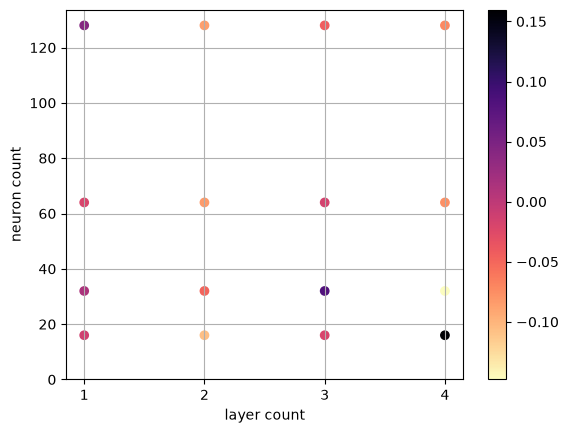

MSE score:


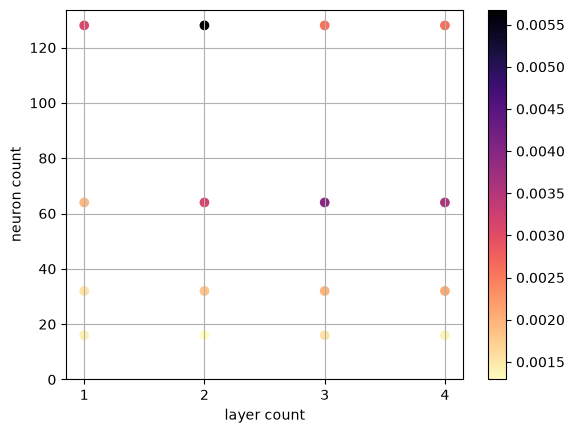


Rank correlations for 6 qubits and 15 gates:


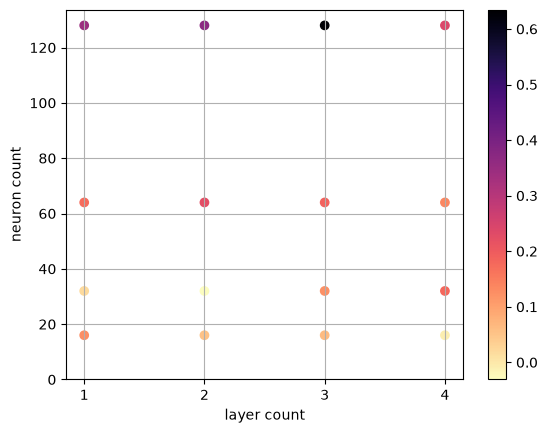

MSE score:


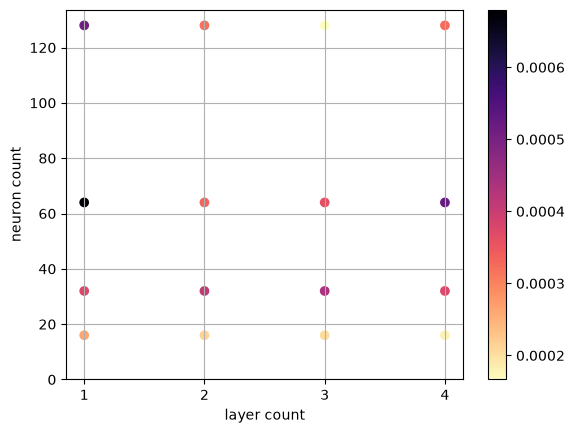


Rank correlations for 6 qubits and 20 gates:


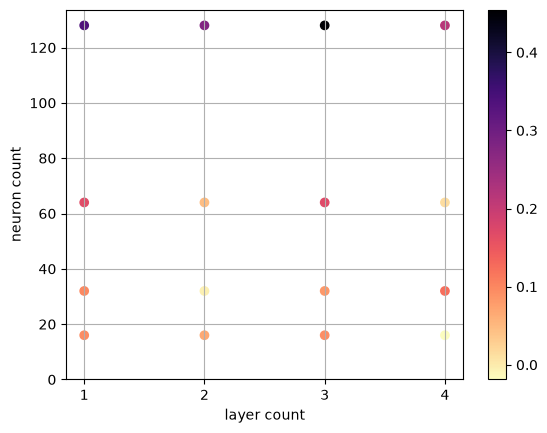

MSE score:


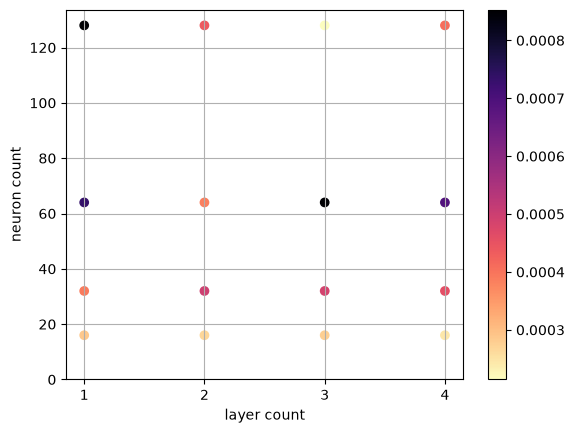

<Figure size 640x480 with 0 Axes>

In [ ]:
qubit_nums = data["qubit_num"].unique()
qubit_nums = sorted(qubit_nums)

gate_counts = data["gate_count"].unique()
gate_counts = sorted(gate_counts)

for qubit_num in qubit_nums:

    for gate_count in gate_counts:
        rel_data = data[
            (data["qubit_num"] == qubit_num) & (data["gate_count"] == gate_count)
        ]

        if len(rel_data) == 0:
            continue

        print(f"\nRank correlations for {qubit_num} qubits and {gate_count} gates:")
        plot_rank_correlation_grid(rel_data)
        # print("MSE score:")
        # plot_mse_grid(rel_data)
